In [3]:
# pip install scikit-learn

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score

In [39]:
## Read the data
housing_df=pd.read_csv('/Users/niteshkumar/Downloads/Ml_projects/housing.csv')
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [40]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [41]:
housing_df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


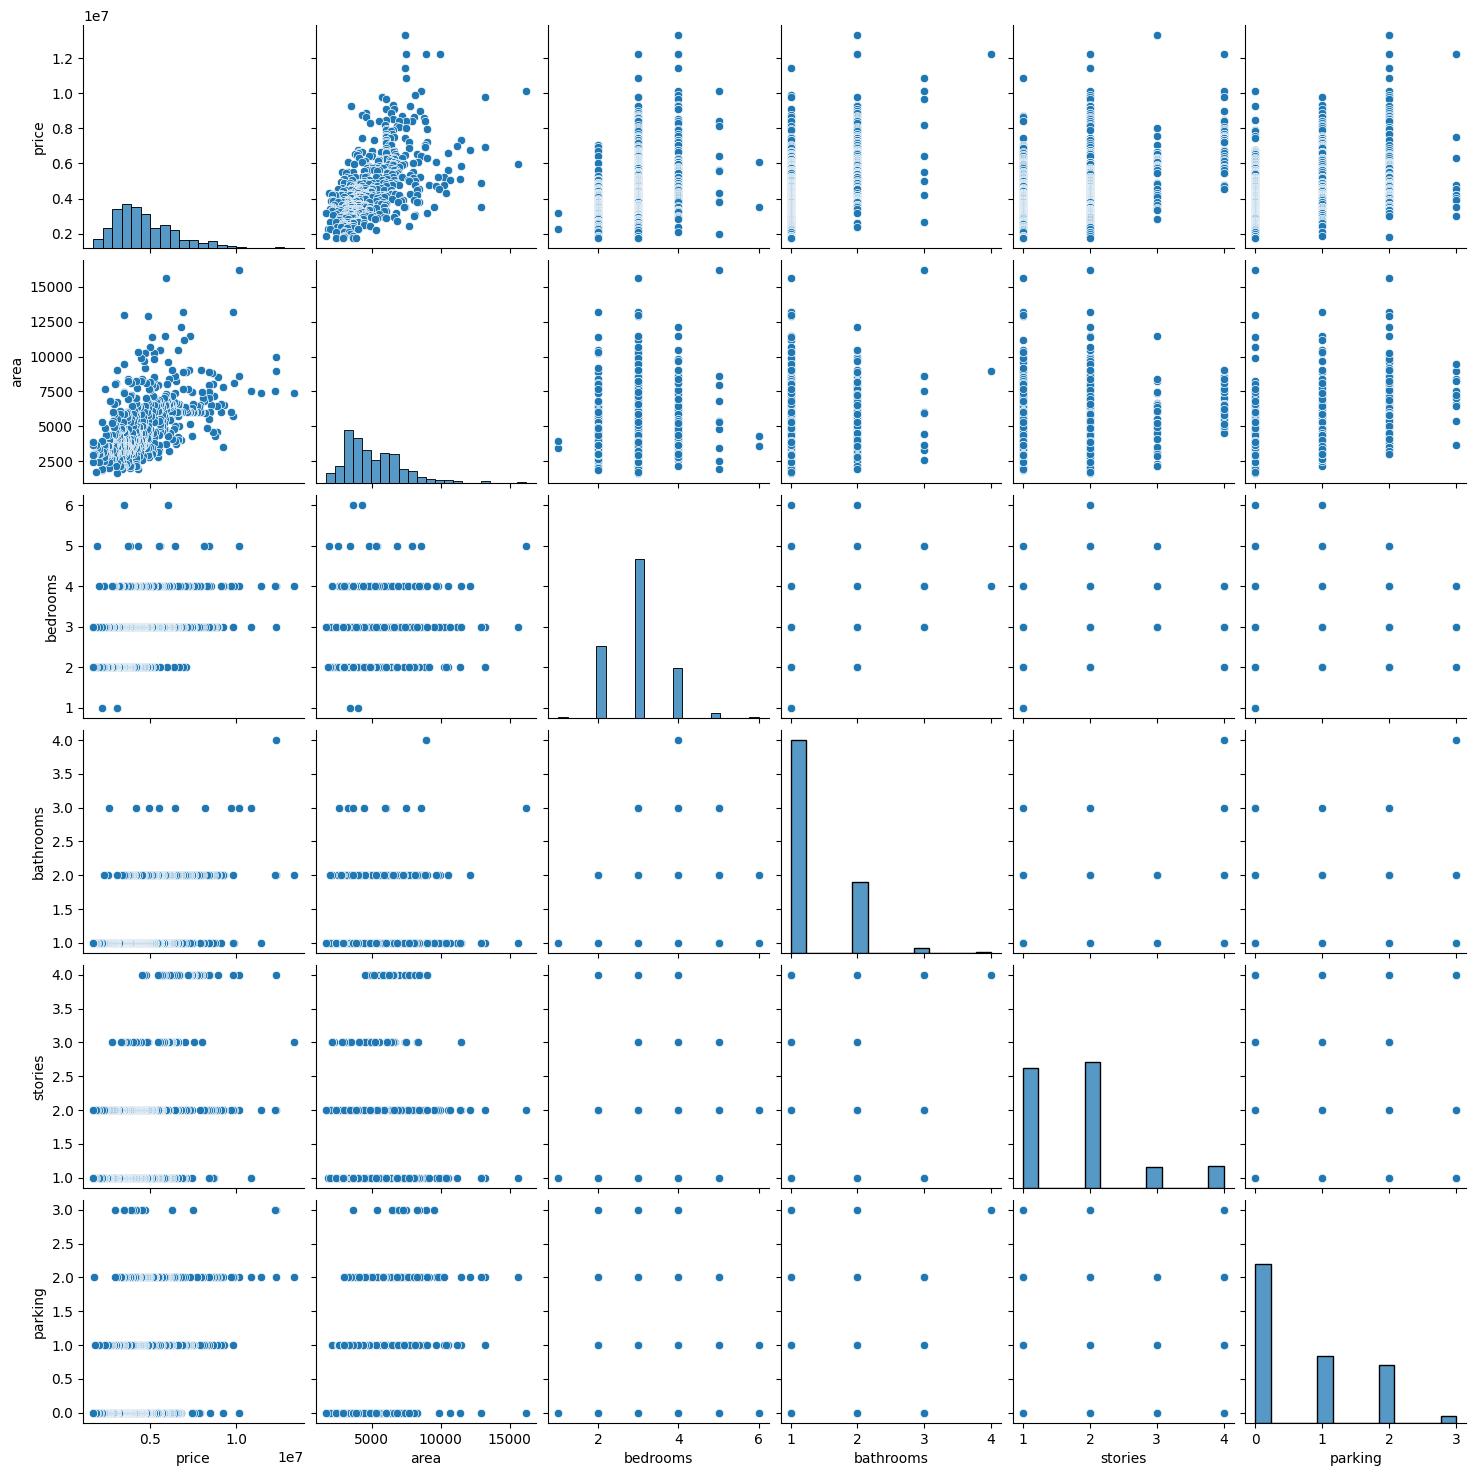

In [42]:
## Visualization of the numerical data
sns.pairplot(housing_df)
plt.show()

In [43]:
housing_df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

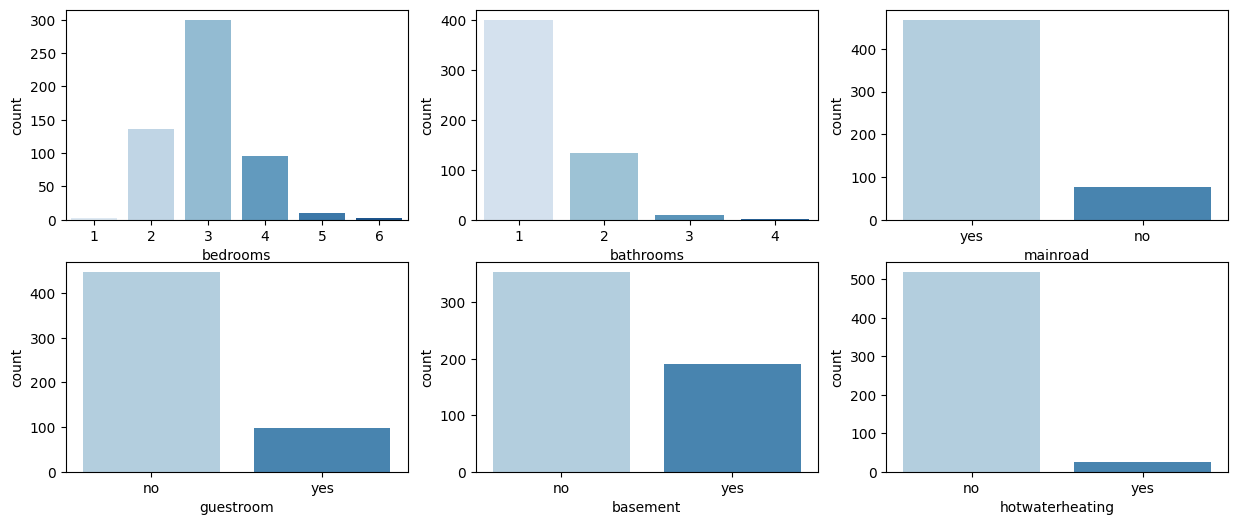

In [44]:
## Visulization of the categorical data
plt.figure(figsize=(15,6))
plt.subplot(2,3,1)
sns.countplot(x='bedrooms',data=housing_df,palette='Blues')
plt.subplot(2,3,2)
sns.countplot(x='bathrooms',data=housing_df,palette='Blues')
plt.subplot(2,3,3)
sns.countplot(x='mainroad',data=housing_df,palette='Blues')
plt.subplot(2,3,4)
sns.countplot(x='guestroom',data=housing_df,palette='Blues')
plt.subplot(2,3,5)
sns.countplot(x='basement',data=housing_df,palette='Blues')
plt.subplot(2,3,6)
sns.countplot(x='hotwaterheating',data=housing_df,palette='Blues')
plt.show()

In [45]:
df.columns

NameError: name 'df' is not defined

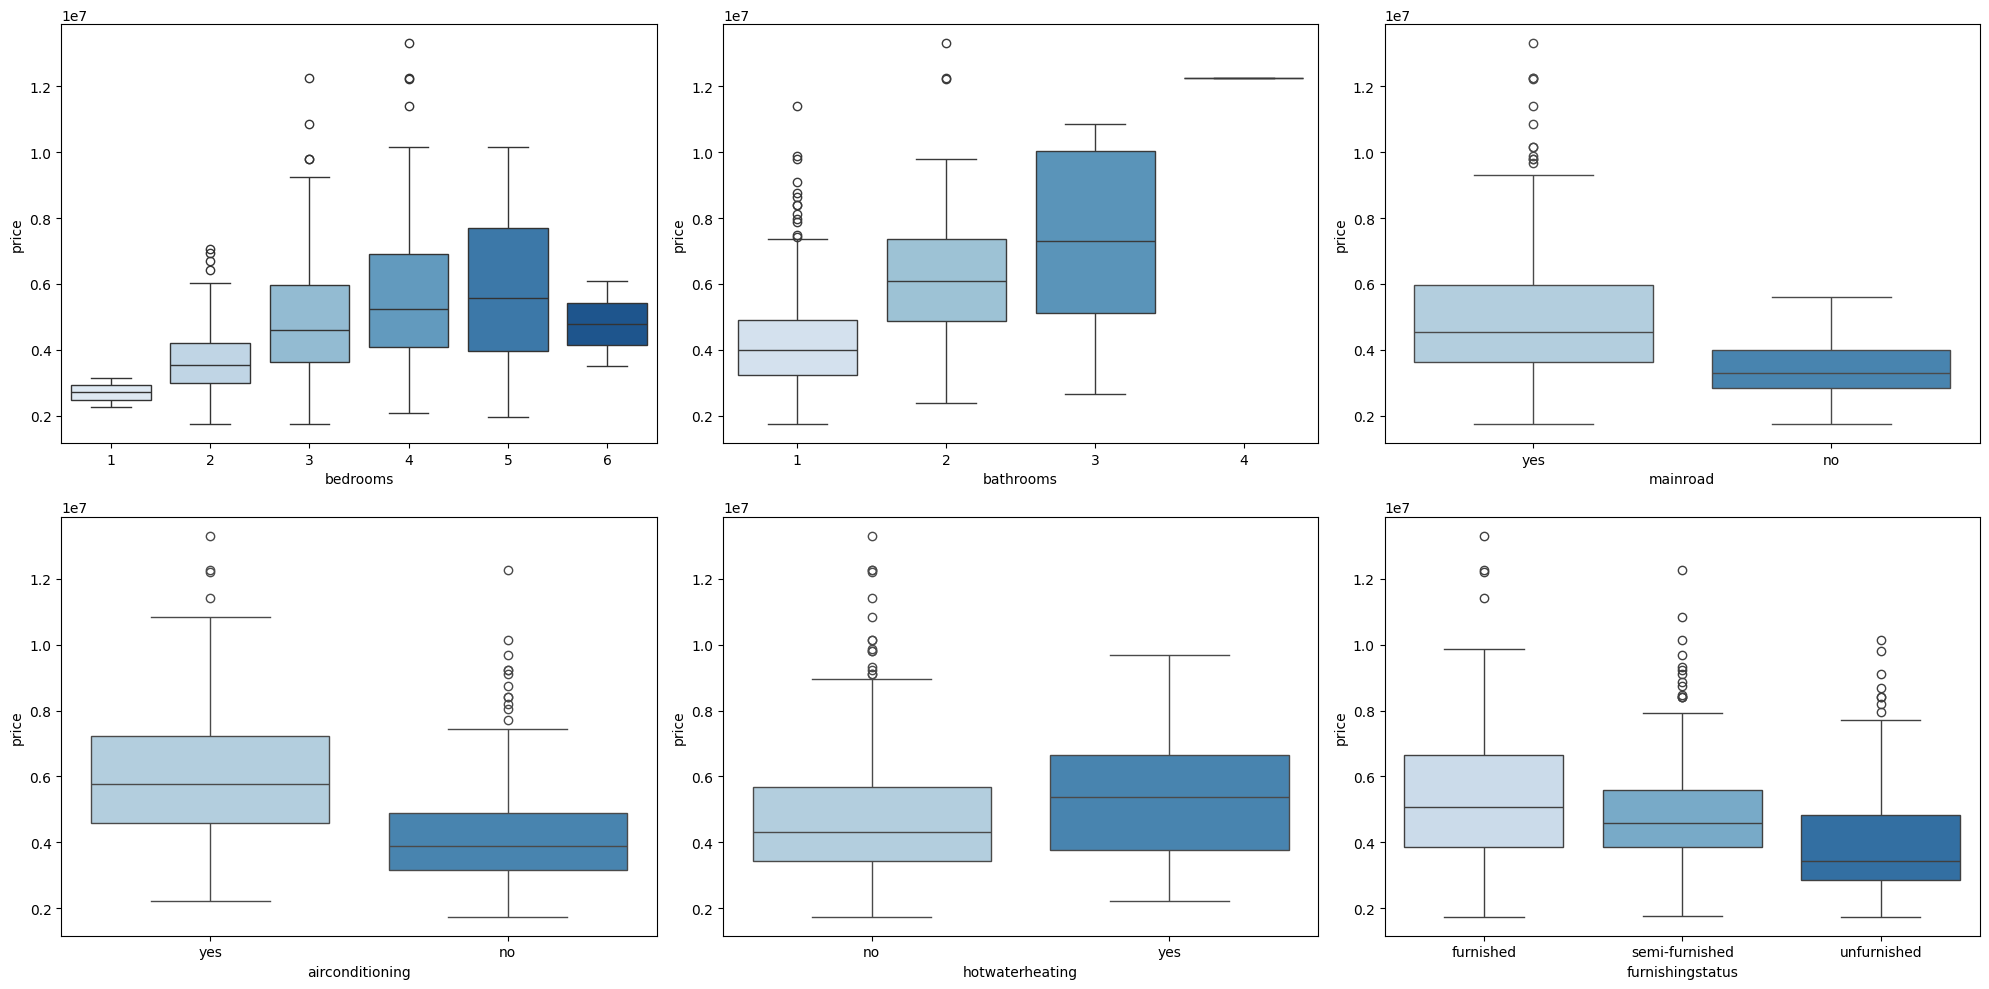

In [46]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.boxplot(x='bedrooms',y='price',data=housing_df,palette='Blues')
plt.subplot(2,3,2)
sns.boxplot(x='bathrooms',y='price',data=housing_df,palette='Blues')
plt.subplot(2,3,3)
sns.boxplot(x='mainroad',y='price',data=housing_df,palette='Blues')
plt.subplot(2,3,4)
sns.boxplot(x='airconditioning',y='price',data=housing_df,palette='Blues')
plt.subplot(2,3,5)
sns.boxplot(x='hotwaterheating',y='price',data=housing_df,palette='Blues')
plt.subplot(2,3,6)
sns.boxplot(x='furnishingstatus',y='price',data=housing_df,palette='Blues')
plt.tight_layout()
plt.show()

In [47]:
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [48]:
## Preparing the data for modeling
## Encoding the categorical 

In [49]:
housing_df.mainroad.value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [50]:
housing_df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [51]:
varlist=['mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning','prefarea']

In [52]:
housing_df[varlist]=housing_df[varlist].apply(lambda x:x.map({'yes':1,'no':0}))

In [53]:
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [54]:
varlist

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea']

In [55]:
# housing_df[varlist]

In [56]:
## Creating dummy variable for Furnishing status
status=pd.get_dummies(housing_df['furnishingstatus'],dtype=int,drop_first=True)
status

,semi-furnished,unfurnished
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
...,...,...
540,0,1
541,1,0
542,0,1
543,0,0


In [57]:
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [58]:
housing_df=pd.concat([housing_df,status],axis=1)
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,0,0


In [59]:
housing_df=housing_df.drop('furnishingstatus',axis=1)
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [60]:
## spliting into train and test dataset
df_train,df_test=train_test_split(housing_df,test_size=0.3,random_state=1)
print(df_train.shape,df_test.shape)

(381, 14) (164, 14)


In [61]:
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [62]:
housing_df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'semi-furnished', 'unfurnished'],
      dtype='str')

In [63]:
# Rescaling the features
##instantiate an object
scaler=MinMaxScaler()
#no need to sclae the binary variable,not required
## Create a list of only numerical variable
num_variable=['area', 'bedrooms', 'bathrooms', 'stories','parking','price']

## Fit on data
df_train[num_variable]=scaler.fit_transform(df_train[num_variable])
df_train[num_variable]



,area,bedrooms,bathrooms,stories,parking,price
180,0.193103,0.6,0.333333,0.000000,0.666667,0.330000
189,0.126897,0.2,0.000000,0.000000,0.000000,0.313333
93,0.379310,0.4,0.333333,0.000000,1.000000,0.433333
444,0.097931,0.4,0.000000,0.333333,0.000000,0.140000
81,0.158621,0.4,0.333333,0.333333,0.333333,0.463333
...,...,...,...,...,...,...
129,0.673103,0.4,0.000000,0.666667,0.666667,0.392667
144,0.206897,0.6,0.000000,0.333333,0.333333,0.366667
72,0.228966,0.4,0.000000,1.000000,0.000000,0.473333
235,0.274483,0.4,0.000000,0.333333,0.333333,0.273333


In [64]:
df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
180,0.330000,0.193103,0.6,0.333333,0.000000,0,0,1,0,1,0.666667,0,1,0
189,0.313333,0.126897,0.2,0.000000,0.000000,0,1,1,0,0,0.000000,0,1,0
93,0.433333,0.379310,0.4,0.333333,0.000000,1,0,1,0,1,1.000000,0,1,0
444,0.140000,0.097931,0.4,0.000000,0.333333,0,0,0,0,0,0.000000,0,0,0
81,0.463333,0.158621,0.4,0.333333,0.333333,1,0,1,0,1,0.333333,0,1,0


In [65]:
df_train[num_variable].min(),df_train[num_variable].max()

(area         0.0
 bedrooms     0.0
 bathrooms    0.0
 stories      0.0
 parking      0.0
 price        0.0
 dtype: float64,
 area         1.0
 bedrooms     1.0
 bathrooms    1.0
 stories      1.0
 parking      1.0
 price        1.0
 dtype: float64)

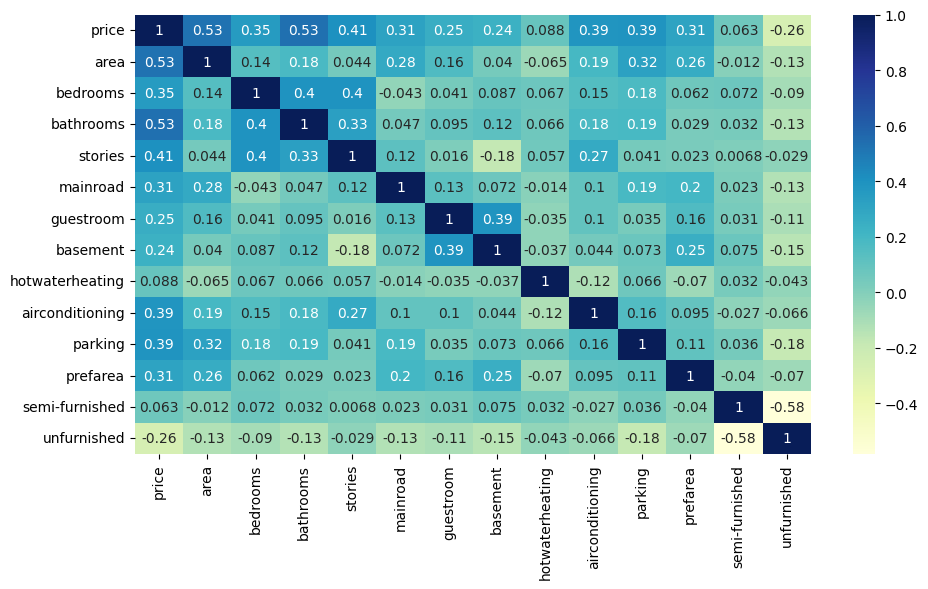

In [66]:
##heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df_train.corr(),annot=True,cmap='YlGnBu')
plt.tight_layout()
plt.show()

In [67]:
df_train.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'semi-furnished', 'unfurnished'],
      dtype='str')

In [68]:
#X_train,y_train
X_train=df_train
y_train=df_train.pop('price')
print(X_train.head())



         area  bedrooms  bathrooms   stories  mainroad  guestroom  basement  \
180  0.193103       0.6   0.333333  0.000000         0          0         1   
189  0.126897       0.2   0.000000  0.000000         0          1         1   
93   0.379310       0.4   0.333333  0.000000         1          0         1   
444  0.097931       0.4   0.000000  0.333333         0          0         0   
81   0.158621       0.4   0.333333  0.333333         1          0         1   

     hotwaterheating  airconditioning   parking  prefarea  semi-furnished  \
180                0                1  0.666667         0               1   
189                0                0  0.000000         0               1   
93                 0                1  1.000000         0               1   
444                0                0  0.000000         0               0   
81                 0                1  0.333333         0               1   

     unfurnished  
180            0  
189            0  
93   

In [69]:
y_train.head()

180    0.330000
189    0.313333
93     0.433333
444    0.140000
81     0.463333
Name: price, dtype: float64

In [70]:
## add_constant
## first take one variable 
X_train_sm=sm.add_constant(X_train['area'])
#create a first model 
lr=sm.OLS(y_train,X_train_sm)
## fit the model
lr_model_first=lr.fit()

#params
lr_model_first.params

const    0.146221
area     0.582309
dtype: float64

In [72]:
lr_model_first.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     144.5
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.05e-28
Time:                        12:24:58   Log-Likelihood:                 192.66
No. Observations:                 381   AIC:                            -381.3
Df Residuals:                     379   BIC:                            -373.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1462      0.014     10.456      0.000       0.119       0.174
area           0.5823      0.048     12.020      0.000       0.487       0.678
==============================================================================
Omnibus:                       52.366   Durbin-Watson:                   2.040
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               86.799
Skew:                           0.830   Prob(JB):                     1.42e-19
Kurtosis:                       4.648   Cond. No.                         6.86
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [73]:
## add another variable 
## go with next varaibale whose corr is more after area
X_train_sm=sm.add_constant(X_train[['area','bathrooms']])
#create a second model 
lr=sm.OLS(y_train,X_train_sm)
## fit the model
lr_model_second=lr.fit()

#params
lr_model_second.params

const        0.123250
area         0.491436
bathrooms    0.460407
dtype: float64

In [74]:
lr_model_second.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     169.8
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.39e-53
Time:                        12:29:13   Log-Likelihood:                 253.26
No. Observations:                 381   AIC:                            -500.5
Df Residuals:                     378   BIC:                            -488.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1233      0.012     10.187      0.000       0.099       0.147
area           0.4914      0.042     11.680      0.000       0.409       0.574
bathrooms      0.4604      0.039     11.899      0.000       0.384       0.536
==============================================================================
Omnibus:                       51.686   Durbin-Watson:                   1.917
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               86.316
Skew:                           0.817   Prob(JB):                     1.81e-19
Kurtosis:                       4.664   Cond. No.                         7.25
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
## add another variable 
## go with next varaibale whose corr is more after area
X_train_sm=sm.add_constant(X_train[['area','bathrooms','stories']])
#create a second model 
lr=sm.OLS(y_train,X_train_sm)
## fit the model
lr_model_third=lr.fit()

#params
lr_model_third.params

const        0.088441
area         0.495969
bathrooms    0.370807
stories      0.162407
dtype: float64

In [76]:
lr_model_third.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     145.7
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.09e-62
Time:                        12:32:03   Log-Likelihood:                 277.78
No. Observations:                 381   AIC:                            -547.6
Df Residuals:                     377   BIC:                            -531.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0884      0.012      7.163      0.000       0.064       0.113
area           0.4960      0.040     12.553      0.000       0.418       0.574
bathrooms      0.3708      0.038      9.655      0.000       0.295       0.446
stories        0.1624      0.023      7.196      0.000       0.118       0.207
==============================================================================
Omnibus:                       71.564   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              155.575
Skew:                           0.970   Prob(JB):                     1.65e-34
Kurtosis:                       5.457   Cond. No.                         7.69
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [77]:
X_train.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'semi-furnished', 'unfurnished'],
      dtype='str')

In [78]:
## add another variable 
## go with next varaibale whose corr is more after area
X_train_sm=sm.add_constant(X_train[['area','bathrooms','stories','airconditioning']])
#create a second model 
lr=sm.OLS(y_train,X_train_sm)
## fit the model
lr_model_fourth=lr.fit()

#params
lr_model_fourth.params

const              0.084891
area               0.461534
bathrooms          0.358012
stories            0.135409
airconditioning    0.068299
dtype: float64

In [79]:
lr_model_fourth.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     122.7
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           6.78e-67
Time:                        12:33:32   Log-Likelihood:                 290.26
No. Observations:                 381   AIC:                            -570.5
Df Residuals:                     376   BIC:                            -550.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0849      0.012      7.083      0.000       0.061       0.108
area                0.4615      0.039     11.867      0.000       0.385       0.538
bathrooms           0.3580      0.037      9.598      0.000       0.285       0.431
stories             0.1354      0.023      6.014      0.000       0.091       0.180
airconditioning     0.0683      0.014      5.045      0.000       0.042       0.095
==============================================================================
Omnibus:                       84.177   Durbin-Watson:                   1.948
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              200.934
Skew:                           1.093   Prob(JB):                     2.33e-44
Kurtosis:                       5.807   Cond. No.                         8.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [80]:
## add another variable 
## go with next varaibale whose corr is more after area
X_train_sm=sm.add_constant(X_train[['area','bathrooms','stories','airconditioning','bedrooms']])
#create a second model 
lr=sm.OLS(y_train,X_train_sm)
## fit the model
lr_model_fifth=lr.fit()

#params
lr_model_fifth.params

const              0.067304
area               0.457297
bathrooms          0.343596
stories            0.126263
airconditioning    0.068260
bedrooms           0.056312
dtype: float64

In [81]:
lr_model_fifth.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     98.67
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           3.54e-66
Time:                        12:34:12   Log-Likelihood:                 291.10
No. Observations:                 381   AIC:                            -570.2
Df Residuals:                     375   BIC:                            -546.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0673      0.018      3.698      0.000       0.032       0.103
area                0.4573      0.039     11.726      0.000       0.381       0.534
bathrooms           0.3436      0.039      8.827      0.000       0.267       0.420
stories             0.1263      0.024      5.350      0.000       0.080       0.173
airconditioning     0.0683      0.014      5.047      0.000       0.042       0.095
bedrooms            0.0563      0.044      1.283      0.200      -0.030       0.143
==============================================================================
Omnibus:                       79.978   Durbin-Watson:                   1.948
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              186.854
Skew:                           1.048   Prob(JB):                     2.66e-41
Kurtosis:                       5.716   Cond. No.                         10.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [82]:
## Second way for modeling ,add all variable at a time and then remove one by one by check p value and vif ..
housing_df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'semi-furnished', 'unfurnished'],
      dtype='str')

In [85]:
## Build the model with all the variable
X_train_sm=sm.add_constant(X_train)
## create the model
lr=sm.OLS(y_train,X_train_sm)

## fit the model
lr_model=lr_model.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     60.33
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.02e-82
Time:                        12:41:38   Log-Likelihood:                 348.94
No. Observations:                 381   AIC:                            -669.9
Df Residuals:                     367   BIC:                            -614.7
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0315      0.023      1.394      0.164      -0.013       0.076
area                0.3411      0.038      9.058      0.000       0.267       0.415
bedrooms            0.0195      0.039      0.495      0.621      -0.058       0.097
bathrooms           0.2918      0.035      8.443      0.000       0.224       0.360
stories             0.1502      0.022      6.901      0.000       0.107       0.193
mainroad            0.0448      0.016      2.868      0.004       0.014       0.076
guestroom           0.0261      0.015      1.750      0.081      -0.003       0.055
basement            0.0522      0.012      4.199      0.000       0.028       0.077
hotwaterheating     0.0778      0.024      3.195      0.002       0.030       0.126
airconditioning     0.0585      0.012      4.887      0.000       0.035       0.082
parking             0.0780      0.019      4.034      0.000       0.040       0.116
prefarea            0.0487      0.013      3.822      0.000       0.024       0.074
semi-furnished     -0.0064      0.013     -0.500      0.617      -0.031       0.019
unfurnished        -0.0377      0.014     -2.693      0.007      -0.065      -0.010
==============================================================================
Omnibus:                       65.695   Durbin-Watson:                   2.100
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              153.511
Skew:                           0.868   Prob(JB):                     4.63e-34
Kurtosis:                       5.580   Cond. No.                         14.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#  VIF — Variance Inflation Factor

### What is VIF?
VIF measures how much one independent variable is correlated with other independent variables in a regression model. It detects **multicollinearity** — when two or more features are highly related to each other.

### Why do we use VIF?
In linear regression, if two features are highly correlated, the model gets confused about which one is actually affecting the output. VIF helps us **detect and remove** redundant features to make the model more accurate and stable.

### How to interpret VIF values?
| VIF Value | Meaning |
|-----------|---------|
| VIF = 1 |  No correlation — perfect! |
| 1 to 5 |  Moderate — acceptable |
| > 5 |     High — consider removing |
| > 10 |    Severe — must remove! |



> **Tip:** Always check VIF **before** training your model. Drop features with VIF > 5 one by one and recalculate!

In [87]:
## create the dataframe that contain the name of all features varaiable 
vif=pd.DataFrame()
vif['features']=X_train.columns
vif['VIF']=[variance_inflation_factor(X_train.values,i) for i in range(X_train.shape[1])]
vif

,features,VIF
0,area,4.474004
1,bedrooms,7.545953
2,bathrooms,1.747369
3,stories,2.734498
4,mainroad,5.746944
5,guestroom,1.488418
6,basement,2.128150
7,hotwaterheating,1.094468
8,airconditioning,1.661101
9,parking,1.980539


In [91]:
vif['VIF']=round(vif['VIF'],2)
vif=vif.sort_values(by='VIF',ascending=False)
vif

,features,VIF
1,bedrooms,7.55
4,mainroad,5.75
0,area,4.47
3,stories,2.73
11,semi-furnished,2.35
6,basement,2.13
9,parking,1.98
12,unfurnished,1.91
2,bathrooms,1.75
8,airconditioning,1.66


In [ ]:
## drop the varaiable which have high p value and high vif and then go with high and low things 
## high -low:
   ## high p value ,low vif--remove these first
   ## low p value ,high vif--remove these after the one above
## low p,low vif--keep this dont delete that

In [92]:
X_train.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'semi-furnished', 'unfurnished'],
      dtype='str')

In [93]:
X=X_train.drop('semi-furnished',axis=1)

In [95]:
## create a model
X_train_sm=sm.add_constant(X)

lr=sm.OLS(y_train,X_train_sm)

lr_model=lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     65.47
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.39e-83
Time:                        13:15:47   Log-Likelihood:                 348.81
No. Observations:                 381   AIC:                            -671.6
Df Residuals:                     368   BIC:                            -620.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0273      0.021      1.302      0.194      -0.014       0.069
area                0.3421      0.038      9.102      0.000       0.268       0.416
bedrooms            0.0182      0.039      0.465      0.642      -0.059       0.095
bathrooms           0.2926      0.034      8.487      0.000       0.225       0.360
stories             0.1502      0.022      6.907      0.000       0.107       0.193
mainroad            0.0449      0.016      2.877      0.004       0.014       0.076
guestroom           0.0263      0.015      1.761      0.079      -0.003       0.056
basement            0.0520      0.012      4.195      0.000       0.028       0.076
hotwaterheating     0.0779      0.024      3.201      0.001       0.030       0.126
airconditioning     0.0588      0.012      4.925      0.000       0.035       0.082
parking             0.0785      0.019      4.070      0.000       0.041       0.116
prefarea            0.0491      0.013      3.873      0.000       0.024       0.074
unfurnished        -0.0336      0.011     -2.971      0.003      -0.056      -0.011
==============================================================================
Omnibus:                       64.831   Durbin-Watson:                   2.096
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              150.664
Skew:                           0.859   Prob(JB):                     1.92e-33
Kurtosis:                       5.557   Cond. No.                         14.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [97]:
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif['VIF']=round(vif['VIF'],2)
vif=vif.sort_values(by='VIF',ascending=False)
vif

,features,VIF
1,bedrooms,6.61
4,mainroad,5.40
0,area,4.47
3,stories,2.73
6,basement,2.12
9,parking,1.97
2,bathrooms,1.73
8,airconditioning,1.66
10,prefarea,1.55
5,guestroom,1.49


In [99]:
X=X.drop('bedrooms',axis=1)
X.head()

,area,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished
180,0.193103,0.333333,0.000000,0,0,1,0,1,0.666667,0,0
189,0.126897,0.000000,0.000000,0,1,1,0,0,0.000000,0,0
93,0.379310,0.333333,0.000000,1,0,1,0,1,1.000000,0,0
444,0.097931,0.000000,0.333333,0,0,0,0,0,0.000000,0,0
81,0.158621,0.333333,0.333333,1,0,1,0,1,0.333333,0,0


In [100]:
X_train_sm=sm.add_constant(X)

lr=sm.OLS(y_train,X_train_sm)

lr_model=lr.fit()
lr_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     71.56
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.79e-84
Time:                        13:23:33   Log-Likelihood:                 348.70
No. Observations:                 381   AIC:                            -673.4
Df Residuals:                     369   BIC:                            -626.1
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0334      0.016      2.056      0.041       0.001       0.065
area                0.3437      0.037      9.194      0.000       0.270       0.417
bathrooms           0.2965      0.033      8.875      0.000       0.231       0.362
stories             0.1537      0.020      7.532      0.000       0.114       0.194
mainroad            0.0437      0.015      2.842      0.005       0.013       0.074
guestroom           0.0260      0.015      1.744      0.082      -0.003       0.055
basement            0.0528      0.012      4.299      0.000       0.029       0.077
hotwaterheating     0.0783      0.024      3.223      0.001       0.031       0.126
airconditioning     0.0588      0.012      4.927      0.000       0.035       0.082
parking             0.0795      0.019      4.151      0.000       0.042       0.117
prefarea            0.0492      0.013      3.887      0.000       0.024       0.074
unfurnished        -0.0337      0.011     -2.985      0.003      -0.056      -0.012
==============================================================================
Omnibus:                       65.530   Durbin-Watson:                   2.095
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.906
Skew:                           0.867   Prob(JB):                     6.27e-34
Kurtosis:                       5.574   Cond. No.                         12.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [107]:
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif['VIF']=round(vif['VIF'],2)
vif=vif.sort_values(by='VIF',ascending=False)
vif

,features,VIF
3,mainroad,4.83
0,area,4.16
2,stories,2.30
5,basement,1.96
8,parking,1.95
1,bathrooms,1.66
7,airconditioning,1.66
9,prefarea,1.54
4,guestroom,1.48
10,unfurnished,1.34


In [108]:
## Residual analysis
y_train_pred=lr_model.predict(X_train_sm)
y_train_pred


180    0.363257
189    0.155835
93     0.497473
444    0.118330
81     0.419842
         ...   
129    0.513190
144    0.363559
72     0.383838
235    0.333974
37     0.614498
Length: 381, dtype: float64

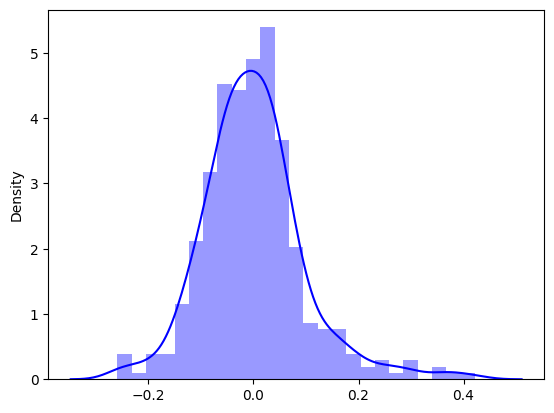

In [116]:
res=y_train-y_train_pred
sns.distplot(res,color='blue')
plt.show()

In [118]:
## Final stage
## predictions and evaluations
num_variable=['area', 'bedrooms', 'bathrooms', 'stories','parking','price']

## Fit on data
df_test[num_variable]=scaler.transform(df_test[num_variable])
df_test[num_variable]


,area,bedrooms,bathrooms,stories,parking,price
62,0.313103,0.6,0.333333,0.333333,0.333333,0.506667
247,0.462069,0.6,0.000000,1.000000,1.000000,0.266667
142,0.606897,0.6,0.333333,0.333333,0.333333,0.366667
107,0.325517,0.4,0.000000,0.666667,0.000000,0.416667
483,0.338966,0.4,0.000000,0.333333,0.000000,0.113333
...,...,...,...,...,...,...
450,0.120690,0.4,0.000000,0.333333,0.000000,0.133333
542,0.132414,0.2,0.000000,0.000000,0.000000,0.000000
408,0.158621,0.2,0.000000,0.000000,0.000000,0.160000
80,0.296552,0.4,0.000000,0.333333,0.333333,0.464667


In [119]:
df_test.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000
mean,0.285433,0.224713,0.380488,0.089431,0.284553,0.865854,0.195122,0.335366,0.042683,0.359756,0.235772,0.207317,0.390244,0.359756
std,0.192734,0.136177,0.135156,0.165528,0.305022,0.341853,0.397508,0.473564,0.202760,0.481399,0.285948,0.406626,0.489299,0.481399
min,0.000000,-0.003448,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.153333,0.124655,0.200000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.233333,0.190000,0.400000,0.000000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.384167,0.314500,0.400000,0.000000,0.333333,1.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,1.000000,1.000000
max,1.100000,0.793103,0.800000,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [120]:
y_test=df_test.pop('price')
X_test=df_test

In [128]:
## add constant
X_test_sm=sm.add_constant(X_test)
X_test_sm

,const,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
62,1.0,0.313103,0.6,0.333333,0.333333,1,0,0,0,1,0.333333,0,0,0
247,1.0,0.462069,0.6,0.000000,1.000000,1,0,0,0,0,1.000000,0,0,1
142,1.0,0.606897,0.6,0.333333,0.333333,1,0,0,0,0,0.333333,0,1,0
107,1.0,0.325517,0.4,0.000000,0.666667,1,0,1,0,0,0.000000,1,0,1
483,1.0,0.338966,0.4,0.000000,0.333333,1,0,0,0,0,0.000000,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,1.0,0.120690,0.4,0.000000,0.333333,1,0,1,0,0,0.000000,0,1,0
542,1.0,0.132414,0.2,0.000000,0.000000,1,0,0,0,0,0.000000,0,0,1
408,1.0,0.158621,0.2,0.000000,0.000000,1,0,0,0,0,0.000000,0,0,1
80,1.0,0.296552,0.4,0.000000,0.333333,1,0,0,1,0,0.333333,1,1,0


In [129]:
X_test_sm=X_test_sm.drop(['bedrooms','semi-furnished'],axis=1)
X_test_sm

,const,area,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished
62,1.0,0.313103,0.333333,0.333333,1,0,0,0,1,0.333333,0,0
247,1.0,0.462069,0.000000,1.000000,1,0,0,0,0,1.000000,0,1
142,1.0,0.606897,0.333333,0.333333,1,0,0,0,0,0.333333,0,0
107,1.0,0.325517,0.000000,0.666667,1,0,1,0,0,0.000000,1,1
483,1.0,0.338966,0.000000,0.333333,1,0,0,0,0,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
450,1.0,0.120690,0.000000,0.333333,1,0,1,0,0,0.000000,0,0
542,1.0,0.132414,0.000000,0.000000,1,0,0,0,0,0.000000,0,1
408,1.0,0.158621,0.000000,0.000000,1,0,0,0,0,0.000000,0,1
80,1.0,0.296552,0.000000,0.333333,1,0,0,1,0,0.333333,1,0


In [130]:
## predict
y_test_pred=lr_model.predict(X_test_sm)
y_test_pred

62     0.420122
247    0.435453
142    0.462312
107    0.359826
483    0.244884
         ...   
450    0.222680
542    0.088962
408    0.097969
80     0.384369
46     0.516886
Length: 164, dtype: float64

In [132]:
## evaluate the model
r2_score(y_true=y_test,y_pred=y_test_pred)

0.6627409101867114

In [ ]:
#Variable Selection using RFE
#automated technique

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [134]:
housing_df=pd.read_csv('/Users/niteshkumar/Downloads/Ml_projects/housing.csv')
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [135]:
#Data prepration
##List of variable to map
varlist=['mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning','prefarea']

housing_df[varlist]=housing_df[varlist].apply(lambda x:x.map({'yes':1,'no':0}))


In [136]:
## Creating dummy variable for Furnishing status
status=pd.get_dummies(housing_df['furnishingstatus'],dtype=int,drop_first=True)
status

,semi-furnished,unfurnished
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
...,...,...
540,0,1
541,1,0
542,0,1
543,0,0


In [138]:
## add the result 
housing_df=pd.concat([housing_df,status],axis=1)
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,0,0


In [139]:
## Drop furnishing status
housing_df.drop(['furnishingstatus'],axis=1,inplace=True)

In [140]:
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [158]:
df_train,df_test=train_test_split(housing_df,test_size=0.3,random_state=1)

In [159]:
## rescaling the features
## we will use min max scaling
## Apply scaler() to all columns except the 'yes-no' and dummy variable
num_variable=['area','bedrooms','bathrooms','stories','parking','price']
df_train[num_variable]=scaler.fit_transform(df_train[num_variable])
df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
180,0.330000,0.193103,0.6,0.333333,0.000000,0,0,1,0,1,0.666667,0,1,0
189,0.313333,0.126897,0.2,0.000000,0.000000,0,1,1,0,0,0.000000,0,1,0
93,0.433333,0.379310,0.4,0.333333,0.000000,1,0,1,0,1,1.000000,0,1,0
444,0.140000,0.097931,0.4,0.000000,0.333333,0,0,0,0,0,0.000000,0,0,0
81,0.463333,0.158621,0.4,0.333333,0.333333,1,0,1,0,1,0.333333,0,1,0


In [160]:
y_train=df_train.pop('price')
X_train=df_train

In [145]:
## Build the model
## This time we will be using the linerregression function Sckitearn for its compatibility  
# with RFE(Which is utility from sklearn)

In [146]:
## RFE(Recursive features elimination)
## Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [148]:
##Running RFE with the output number of variable equal to 10
from sklearn.feature_selection import RFE

lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(estimator=lm, n_features_to_select=10)
rfe.fit(X_train, y_train)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,LinearRegression,LinearRegression()
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea','semi-furnished', 'unfurnished']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(10)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,13
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](13,)","[1,3,1,...,1,4,1]"


In [161]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('area', np.True_, np.int64(1)),
 ('bedrooms', np.False_, np.int64(3)),
 ('bathrooms', np.True_, np.int64(1)),
 ('stories', np.True_, np.int64(1)),
 ('mainroad', np.True_, np.int64(1)),
 ('guestroom', np.False_, np.int64(2)),
 ('basement', np.True_, np.int64(1)),
 ('hotwaterheating', np.True_, np.int64(1)),
 ('airconditioning', np.True_, np.int64(1)),
 ('parking', np.True_, np.int64(1)),
 ('prefarea', np.True_, np.int64(1)),
 ('semi-furnished', np.False_, np.int64(4)),
 ('unfurnished', np.True_, np.int64(1))]

In [162]:
col=X_train.columns[rfe.support_]
col

Index(['area', 'bathrooms', 'stories', 'mainroad', 'basement',
       'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'unfurnished'],
      dtype='str')

In [163]:
X_train.columns[~rfe.support_]

Index(['bedrooms', 'guestroom', 'semi-furnished'], dtype='str')

In [164]:
## Building model with statsmodel,for the detailed stastics
## creating X_test dataframe with RFE Selected variable
X_train_rfe=X_train[col]
X_train_rfe

,area,bathrooms,stories,mainroad,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished
180,0.193103,0.333333,0.000000,0,1,0,1,0.666667,0,0
189,0.126897,0.000000,0.000000,0,1,0,0,0.000000,0,0
93,0.379310,0.333333,0.000000,1,1,0,1,1.000000,0,0
444,0.097931,0.000000,0.333333,0,0,0,0,0.000000,0,0
81,0.158621,0.333333,0.333333,1,1,0,1,0.333333,0,0
...,...,...,...,...,...,...,...,...,...,...
129,0.673103,0.000000,0.666667,1,0,0,0,0.666667,1,0
144,0.206897,0.000000,0.333333,1,1,0,1,0.333333,0,0
72,0.228966,0.000000,1.000000,1,0,0,1,0.000000,1,1
235,0.274483,0.000000,0.333333,1,0,0,1,0.333333,0,0


In [165]:
# Adding a constant variable
X_train_rfe=sm.add_constant(X_train_rfe)
lm=sm.OLS(y_train,X_train_rfe).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     77.98
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           8.81e-85
Time:                        17:10:08   Log-Likelihood:                 347.13
No. Observations:                 381   AIC:                            -672.3
Df Residuals:                     370   BIC:                            -628.9
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0316      0.016     

In [166]:
vif=pd.DataFrame()
vif['features']=X_train_rfe.columns
vif['VIF']=[variance_inflation_factor(X_train_rfe.values,i) for i in range(X_train_rfe.shape[1])]
vif['VIF']=round(vif['VIF'],2)
vif=vif.sort_values(by='VIF',ascending=False)
vif

,features,VIF
0,const,10.36
1,area,1.29
3,stories,1.29
2,bathrooms,1.24
8,parking,1.19
5,basement,1.18
7,airconditioning,1.17
9,prefarea,1.17
4,mainroad,1.15
10,unfurnished,1.08


In [167]:
y_train_price=lm.predict(X_train_rfe)

Text(0.5, 0, 'Errors')

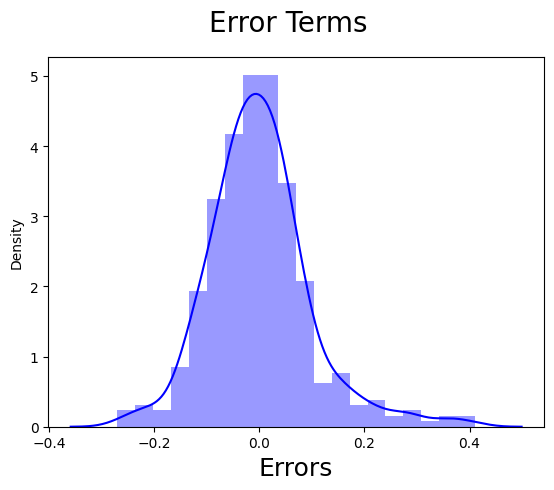

In [169]:
## plot the histogram for error term
fig=plt.figure()
sns.distplot((y_train-y_train_price),bins=20,color='blue')
fig.suptitle('Error Terms',fontsize=20)
plt.xlabel('Errors',fontsize=18)


In [ ]:
## Making the predictions
num_variable=['area','bedrooms','bathrooms','stories','parking','price']